# Configuración básica (no tocar)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [2]:
x = Variable()

# Implementación de métodos

In [3]:
def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()

    fa = df.eval(a)
    fb = df.eval(b)

    if fa * fb > 0:
        raise ValueError("La derivada no cambia de signo en el intervalo dado")

    for step in range(1, max_iter + 1):
        xn = (a + b) / 2
        fxn = df.eval(xn)

        if abs(fxn) < tol or abs(b - a) < tol:
            return xn, step

        if fa * fxn < 0:
            b = xn
            fb = fxn
        else:
            a = xn
            fa = fxn

    return xn, max_iter


def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    ddf = df.derivative()

    xn = x0

    for step in range(1, max_iter + 1):
        dfxn = df.eval(xn)
        ddfxn = ddf.eval(xn)

        if abs(ddfxn) < 1e-12:
            raise ValueError("La segunda derivada es muy cercana a cero")

        x_next = xn - dfxn / ddfxn

        if abs(x_next - xn) < tol:
            return x_next, step

        xn = x_next

    return xn, max_iter


def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()

    xn = x0

    for step in range(1, max_iter + 1):
        gradiente = df.eval(xn)
        x_next = xn - lr * gradiente

        if abs(x_next - xn) < tol:
            return x_next, step

        xn = x_next

    return xn, max_iter

### Prueba de métodos

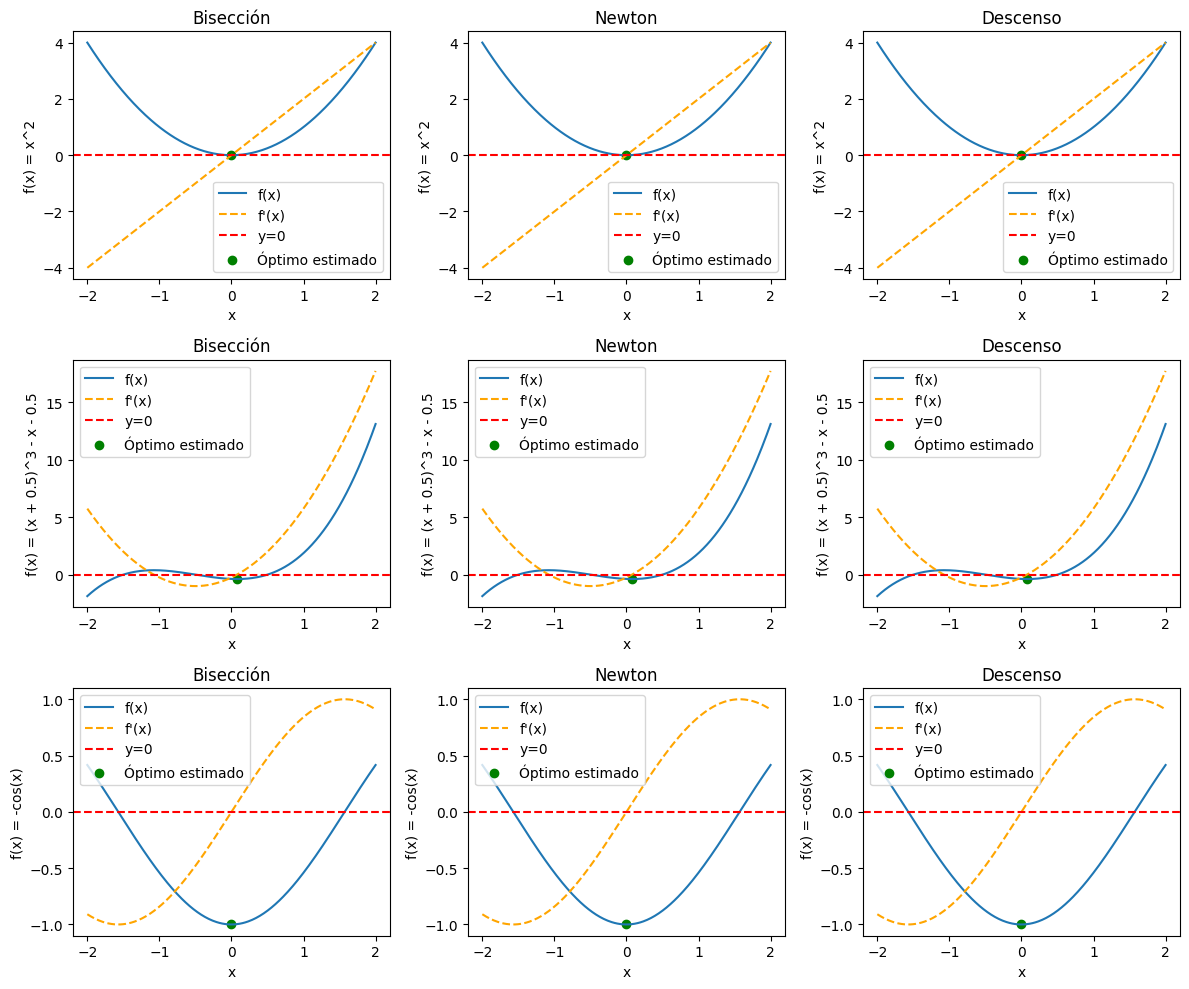

In [14]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

In [ ]:
# Resultados numéricos de la verificación
print("f1 = x²")
print("Bisección:", biseccion(f1, -1, 1))
print("Newton:", newton(f1, 1))
print("Gradiente:", descenso_gradiente(f1, 1, lr=0.01))

print()

print("f2")
print("Bisección:", biseccion(f2, -1, 1))
print("Newton:", newton(f2, 1))
print("Gradiente:", descenso_gradiente(f2, 1, lr=0.01))

print()

print("f3")
print("Bisección:", biseccion(f3, -1, 1))
print("Newton:", newton(f3, 1))
print("Gradiente:", descenso_gradiente(f3, 1, lr=0.01))

f1 = x²
Bisección: (0.0, 1)
Newton: (0.0, 2)
Gradiente: (4.8220225910828e-05, 492)

f2
Bisección: (0.07735013961791992, 22)
Newton: (0.07735026918962574, 6)
Gradiente: (0.07737808501133076, 278)

f3
Bisección: (0.0, 1)
Newton: (np.float64(0.0), 5)
Gradiente: (np.float64(9.836982761146878e-05), 927)


# Aplicación a función no trivial

In [11]:
f = x**2 + 2*sin(3*x)

In [13]:
# Grafica de la función


In [ ]:
# Evaluación de métodos y generación de tablas

# Ajuste de datos

In [16]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

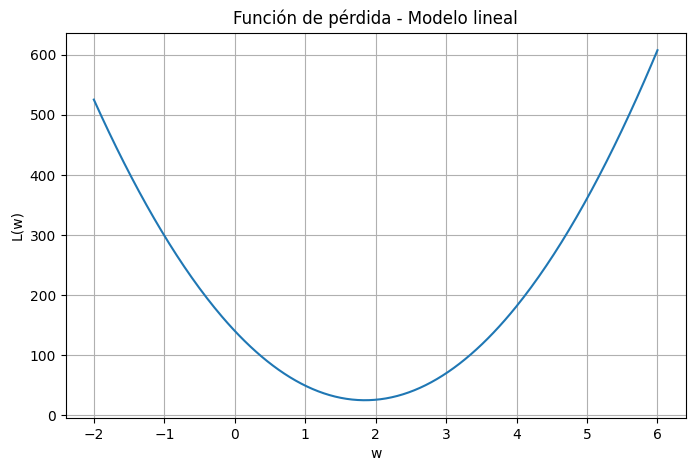

In [ ]:
# Modelo lineal
def perdida_lineal(df):
    L = 0
    
    for _, row in df.iterrows():
        xi = row["x"]
        yi = row["y"]
        y_hat = w * xi
        error = y_hat - yi
        L = L + error**2
    
    return L / len(df)


L_lineal = perdida_lineal(df_linear)
valores_w = np.linspace(-2, 6, 300)
valores_L = np.array([L_lineal.eval(v) for v in valores_w])

# Gráfica de la función de pérdida para el modelo lineal
plt.figure(figsize=(8, 5))
plt.plot(valores_w, valores_L)
plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Función de pérdida - Modelo lineal")
plt.grid(True)
plt.show()

In [ ]:
# Optimice la función de pérdida para el modelo lineal
w_opt, iteraciones = descenso_gradiente(L_lineal, x0=0, lr=0.01)

print("w óptimo:", w_opt)
print("Iteraciones:", iteraciones)
print("Pérdida mínima aproximada:", L_lineal.eval(w_opt))

w óptimo: 1.8479933639545483
Iteraciones: 14
Pérdida mínima aproximada: 25.242043776120045


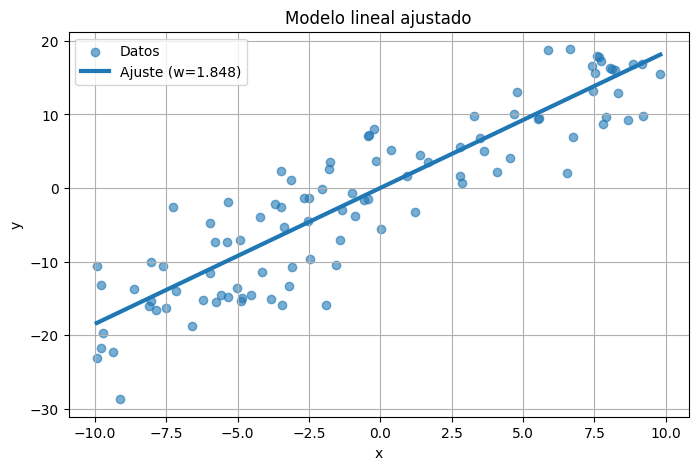

In [ ]:
# Grafique datos y ajuste para el modelo lineal
plt.figure(figsize=(8, 5))

# Datos originales
plt.scatter(df_linear["x"], df_linear["y"], alpha=0.6, label="Datos")

# Modelo ajustado
x_plot = np.linspace(
    df_linear["x"].min(),
    df_linear["x"].max(),
    200
)

y_plot = w_opt * x_plot

plt.plot(x_plot, y_plot, linewidth=3, label=f"Ajuste (w={w_opt:.3f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Modelo lineal ajustado")
plt.legend()
plt.grid(True)

plt.show()

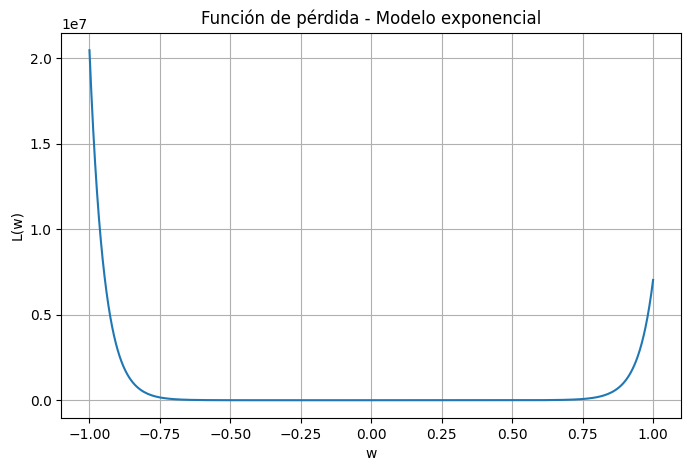

In [23]:
# Modelo exponencial
def perdida_exponencial(df):
    L = 0

    for _, row in df.iterrows():
        xi = row["x"]
        yi = row["y"]

        y_hat = exp(w * xi)

        error = y_hat - yi

        L = L + error**2

    return L / len(df)


L_exp = perdida_exponencial(df_exp)

# Gráfica de la función de pérdida para el modelo exponencial
valores_w = np.linspace(-1, 1, 300)
valores_L = np.array([L_exp.eval(v) for v in valores_w])

plt.figure(figsize=(8,5))
plt.plot(valores_w, valores_L)

plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Función de pérdida - Modelo exponencial")
plt.grid(True)

plt.show()

In [24]:
# Optimice la función de pérdida para el modelo exponencial
w_opt_exp, iteraciones_exp = descenso_gradiente(
    L_exp,
    x0=0,
    lr=0.001
)

print("w óptimo:", w_opt_exp)
print("Iteraciones:", iteraciones_exp)
print("Pérdida mínima:", L_exp.eval(w_opt_exp))

w óptimo: 0.21257605307354413
Iteraciones: 14
Pérdida mínima: 0.9943782645836385


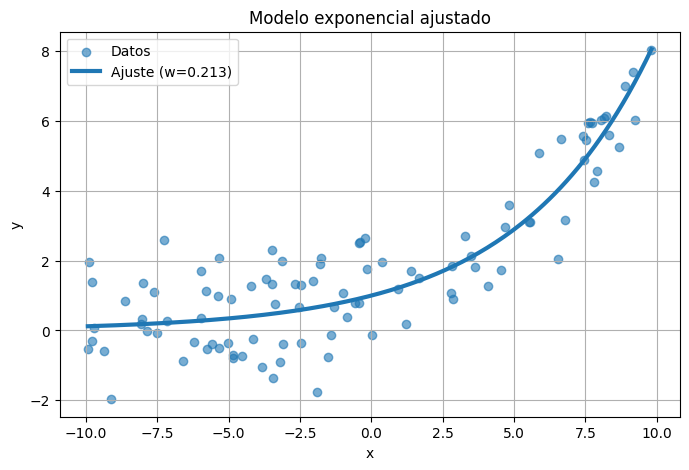

In [25]:
# Grafique datos y ajuste para el modelo exponencial

plt.figure(figsize=(8, 5))

plt.scatter(df_exp["x"], df_exp["y"], alpha=0.6, label="Datos")

x_plot = np.linspace(
    df_exp["x"].min(),
    df_exp["x"].max(),
    200
)

y_plot = np.exp(w_opt_exp * x_plot)

plt.plot(x_plot, y_plot, linewidth=3, label=f"Ajuste (w={w_opt_exp:.3f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Modelo exponencial ajustado")
plt.legend()
plt.grid(True)

plt.show()

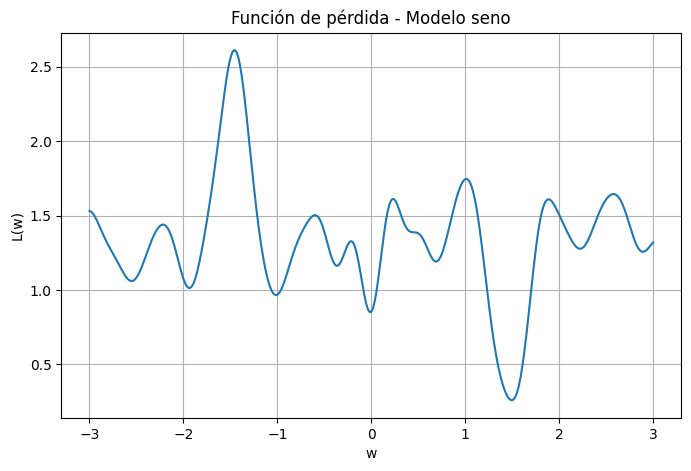

In [26]:
# Función de pérdida para el modelo seno

def perdida_seno(df):
    L = 0

    for _, row in df.iterrows():
        xi = row["x"]
        yi = row["y"]

        y_hat = sin(w * xi)

        error = y_hat - yi

        L = L + error**2

    return L / len(df)


L_sin = perdida_seno(df_sin)

# Gráfico de la función de pérdida

valores_w = np.linspace(-3, 3, 500)
valores_L = np.array([L_sin.eval(v) for v in valores_w])

plt.figure(figsize=(8,5))
plt.plot(valores_w, valores_L)

plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Función de pérdida - Modelo seno")
plt.grid(True)

plt.show()

In [27]:
# Optimización del modelo seno

w_opt_sin, iteraciones_sin = descenso_gradiente(
    L_sin,
    x0=1.5,
    lr=0.01
)

print("w óptimo:", w_opt_sin)
print("Iteraciones:", iteraciones_sin)
print("Pérdida mínima:", L_sin.eval(w_opt_sin))

w óptimo: 1.4949827245063096
Iteraciones: 23
Pérdida mínima: 0.25985981910251416


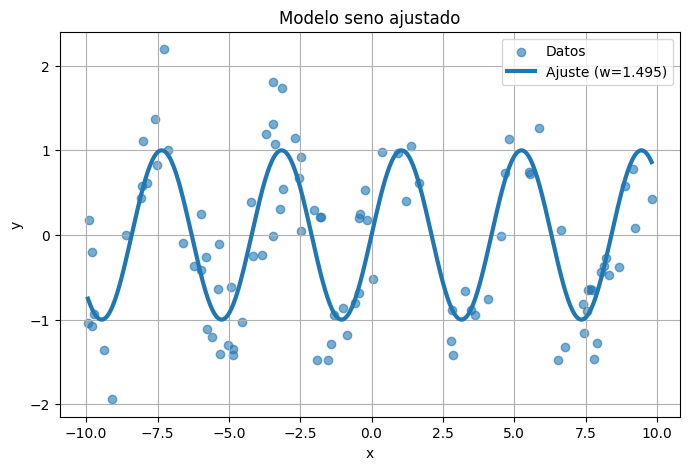

In [28]:
# Grafique datos y ajuste para el modelo seno

plt.figure(figsize=(8, 5))

plt.scatter(df_sin["x"], df_sin["y"], alpha=0.6, label="Datos")

x_plot = np.linspace(
    df_sin["x"].min(),
    df_sin["x"].max(),
    500
)

y_plot = np.sin(w_opt_sin * x_plot)

plt.plot(x_plot, y_plot, linewidth=3, label=f"Ajuste (w={w_opt_sin:.3f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Modelo seno ajustado")
plt.legend()
plt.grid(True)

plt.show()

# BONUS: